In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import unicodedata
from sklearn.metrics import mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error, r2_score
!pip install kmodes
from kmodes.kmodes import KModes
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [41]:
#Conectarse a drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [42]:
# Cargar el archivo especificando el separador correcto y la codificación
ruta_archivo = '/content/drive/MyDrive/Datos_ICFES/Saber11_limpio.csv'
df = pd.read_csv(ruta_archivo, sep=';', encoding='utf-8')

df.head()

,periodo,cole_area_ubicacion,cole_caracter,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,estu_dedicacioninternet,estu_dedicacionlecturadiaria,estu_genero,estu_horassemanatrabaja,...,fami_tieneserviciotv,fami_trabajolabormadre,fami_trabajolaborpadre,punt_c_naturales,punt_global,punt_ingles,punt_lectura_critica,punt_matematicas,punt_sociales_ciudadanas,Año
0,20222,rural,tecnicoacademico,noche,cali,oficial,30minutosomenos,entre1y2horas,m,0,...,si,trabajacomopersonaldelimpiezamantenimientosegu...,noaplica,32,203,50.0,47,42,38,2022
1,20222,urbano,tecnico,completa,cali,nooficial,entre1y3horas,noleoporentretenimiento,m,0,...,si,nosabe,trabajaporcuentapropiaporejemploplomeroelectri...,44,224,52.0,48,47,38,2022
2,20222,urbano,academico,unica,cali,oficial,entre1y3horas,noleoporentretenimiento,f,0,...,si,trabajacomopersonaldelimpiezamantenimientosegu...,trabajaporcuentapropiaporejemploplomeroelectri...,43,223,35.0,53,46,40,2022
3,20222,urbano,tecnicoacademico,tarde,cali,nooficial,entre30y60minutos,30minutosomenos,f,0,...,si,noaplica,noaplica,46,235,37.0,48,49,48,2022
4,20222,rural,tecnicoacademico,manana,palmira,oficial,masde3horas,entre30y60minutos,f,0,...,si,tieneuntrabajodetipoauxiliaradministrativopore...,esduenodeunnegociopequenotienepocosempleadoson...,58,287,49.0,62,57,55,2022


In [43]:
df.columns

Index(['periodo', 'cole_area_ubicacion', 'cole_caracter', 'cole_jornada',
       'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_dedicacioninternet',
       'estu_dedicacionlecturadiaria', 'estu_genero',
       'estu_horassemanatrabaja', 'estu_mcpio_reside',
       'fami_comecarnepescadohuevo', 'fami_comecerealfrutoslegumbre',
       'fami_comelechederivados', 'fami_cuartoshogar', 'fami_educacionmadre',
       'fami_educacionpadre', 'fami_estratovivienda', 'fami_numlibros',
       'fami_personashogar', 'fami_situacioneconomica', 'fami_tieneautomovil',
       'fami_tienecomputador', 'fami_tieneconsolavideojuegos',
       'fami_tienehornomicroogas', 'fami_tieneinternet', 'fami_tienelavadora',
       'fami_tienemotocicleta', 'fami_tieneserviciotv',
       'fami_trabajolabormadre', 'fami_trabajolaborpadre', 'punt_c_naturales',
       'punt_global', 'punt_ingles', 'punt_lectura_critica',
       'punt_matematicas', 'punt_sociales_ciudadanas', 'Año'],
      dtype='object')

In [44]:
columnas_excluir = [
    'punt_c_naturales',
    'punt_ingles',
    'punt_lectura_critica',
    'punt_matematicas',
    'punt_sociales_ciudadanas'

]

df = df.drop(
    columns=columnas_excluir,
    errors="ignore"
).copy()

def limpiar_texto(x):
    if pd.isna(x):
        return x

    x = str(x).lower().strip()
    x = unicodedata.normalize("NFKD", x)
    x = "".join(c for c in x if not unicodedata.combining(c))

    return x

columnas_texto = df.select_dtypes(include="object").columns

df[columnas_texto] = df[columnas_texto].apply(
    lambda columna: columna.map(limpiar_texto)
)

In [45]:
df.columns

Index(['periodo', 'cole_area_ubicacion', 'cole_caracter', 'cole_jornada',
       'cole_mcpio_ubicacion', 'cole_naturaleza', 'estu_dedicacioninternet',
       'estu_dedicacionlecturadiaria', 'estu_genero',
       'estu_horassemanatrabaja', 'estu_mcpio_reside',
       'fami_comecarnepescadohuevo', 'fami_comecerealfrutoslegumbre',
       'fami_comelechederivados', 'fami_cuartoshogar', 'fami_educacionmadre',
       'fami_educacionpadre', 'fami_estratovivienda', 'fami_numlibros',
       'fami_personashogar', 'fami_situacioneconomica', 'fami_tieneautomovil',
       'fami_tienecomputador', 'fami_tieneconsolavideojuegos',
       'fami_tienehornomicroogas', 'fami_tieneinternet', 'fami_tienelavadora',
       'fami_tienemotocicleta', 'fami_tieneserviciotv',
       'fami_trabajolabormadre', 'fami_trabajolaborpadre', 'punt_global',
       'Año'],
      dtype='object')

In [46]:
df.shape

(169004, 33)

In [47]:
df.isna().sum()

,0
periodo,0
cole_area_ubicacion,0
cole_caracter,0
cole_jornada,0
cole_mcpio_ubicacion,0
cole_naturaleza,0
estu_dedicacioninternet,0
estu_dedicacionlecturadiaria,0
estu_genero,0
estu_horassemanatrabaja,0


In [48]:
# Variable objetivo
y = df['punt_global']

# Variables independientes
X = df.drop(columns=['punt_global']).astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#KNN

In [63]:
# ============================================================
# KNN REGRESSOR PARA VARIABLES CATEGÓRICAS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)


# ============================================================
# 1. CODIFICADOR DE VARIABLES CATEGÓRICAS
# ============================================================

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)


# ============================================================
# 2. MODELO KNN
# ============================================================

knn = KNeighborsRegressor(
    n_neighbors=15,
    weights="uniform",
    metric="hamming",
    algorithm="brute",
    n_jobs=-1
)


# ============================================================
# 3. PIPELINE
# ============================================================

modelo_knn = Pipeline([
    ("encoder", encoder),
    ("knn", knn)
])


# ============================================================
# 4. ENTRENAMIENTO
# ============================================================

modelo_knn.fit(
    X_train,
    y_train
)


# ============================================================
# 5. PREDICCIÓN EN TEST
# ============================================================

y_pred_test_knn = modelo_knn.predict(
    X_test
)


# ============================================================
# 6. MÉTRICAS
# ============================================================

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test_knn
    )
)

mae_test = mean_absolute_error(
    y_test,
    y_pred_test_knn
)

mape_test = (
    mean_absolute_percentage_error(
        y_test,
        y_pred_test_knn
    ) * 100
)

r2_test = r2_score(
    y_test,
    y_pred_test_knn
)


print("=== Métricas KNN Regressor ===")
print(f"RMSE:      {rmse_test:.3f}")
print(f"MAE:       {mae_test:.3f}")
print(f"MAPE (%):  {mape_test:.3f}")
print(f"R2:        {r2_test:.3f}")

=== Métricas KNN Regressor ===
RMSE:      45.760
MAE:       37.172
MAPE (%):  15.621
R2:        0.239


# Random Forest

In [49]:
# ---------------------------------------------------------------
# 1. Métricas: RMSE, MAE, MAPE, R2
# ---------------------------------------------------------------
def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    mask = y_real != 0  # MAPE no está definido si y_real = 0
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_real[mask], np.asarray(y_pred)[mask]) * 100,
        "R2": r2_score(y_real, y_pred),
    }

In [50]:
# ---------------------------------------------------------------
# 2. Pipeline: One-Hot (categóricas) + Random Forest
#    min_frequency agrupa categorías muy raras para no inflar columnas
# ---------------------------------------------------------------
pipe = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)),
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

In [51]:
# ---------------------------------------------------------------
# 3. Búsqueda de hiperparámetros (rápida)
# ---------------------------------------------------------------
# One-Hot una sola vez (matriz dispersa) en vez de repetirlo en cada ajuste
enc = OneHotEncoder(handle_unknown="ignore", min_frequency=0.01)
X_train_enc = enc.fit_transform(X_train)

param_dist = {
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [5, 10, 20],
    "max_features": ["sqrt", 0.3],
    "max_samples": [0.3, 0.5],      # cada árbol usa solo 30-50% de las filas
}

busqueda = RandomizedSearchCV(
    RandomForestRegressor(n_estimators=100, random_state=42),  # sin n_jobs aquí
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,                       # paralelismo solo en la búsqueda
    verbose=1,
)
busqueda.fit(X_train_enc, y_train)

print("\nMejores hiperparámetros:", busqueda.best_params_)
print("MAE en validación cruzada:", round(-busqueda.best_score_, 3))

# Pipeline final con el encoder ya ajustado y el mejor bosque,
# así el resto del script (predict, importancias) funciona igual
modelo = Pipeline([("onehot", enc), ("rf", busqueda.best_estimator_)])

Fitting 2 folds for each of 5 candidates, totalling 10 fits

Mejores hiperparámetros: {'min_samples_leaf': 5, 'max_samples': 0.3, 'max_features': 0.3, 'max_depth': 20}
MAE en validación cruzada: 35.289


In [52]:
met = {
    "train": calcular_metricas(y_train, modelo.predict(X_train)),
    "test": calcular_metricas(y_test, modelo.predict(X_test)),
}
print("\n=== Métricas del modelo final ===")
print(pd.DataFrame(met).round(3))

# Baseline: predecir siempre la media de train
base = calcular_metricas(y_test, np.full(len(y_test), y_train.mean()))
print("\n=== Baseline (predecir la media) en test ===")
print(pd.Series(base).round(3))



=== Métricas del modelo final ===
           train    test
RMSE      39.667  43.218
MAE       32.133  35.012
MAPE (%)  13.221  14.377
R2         0.431   0.321

=== Baseline (predecir la media) en test ===
RMSE        52.445
MAE         43.215
MAPE (%)    17.836
R2          -0.000
dtype: float64



=== Importancia por variable ===
 variable
cole_jornada                     0.1623
fami_tienecomputador             0.0675
estu_mcpio_reside                0.0481
cole_mcpio_ubicacion             0.0450
fami_numlibros                   0.0437
estu_dedicacionlecturadiaria     0.0431
fami_educacionmadre              0.0429
cole_naturaleza                  0.0423
fami_educacionpadre              0.0383
fami_situacioneconomica          0.0344
estu_dedicacioninternet          0.0336
fami_trabajolaborpadre           0.0302
periodo                          0.0297
fami_trabajolabormadre           0.0274
estu_horassemanatrabaja          0.0248
fami_comecerealfrutoslegumbre    0.0246
estu_genero                      0.0239
fami_comelechederivados          0.0238
fami_cuartoshogar                0.0234
fami_estratovivienda             0.0234
cole_caracter                    0.0230
fami_comecarnepescadohuevo       0.0211
Año                              0.0189
fami_personashogar               0.0

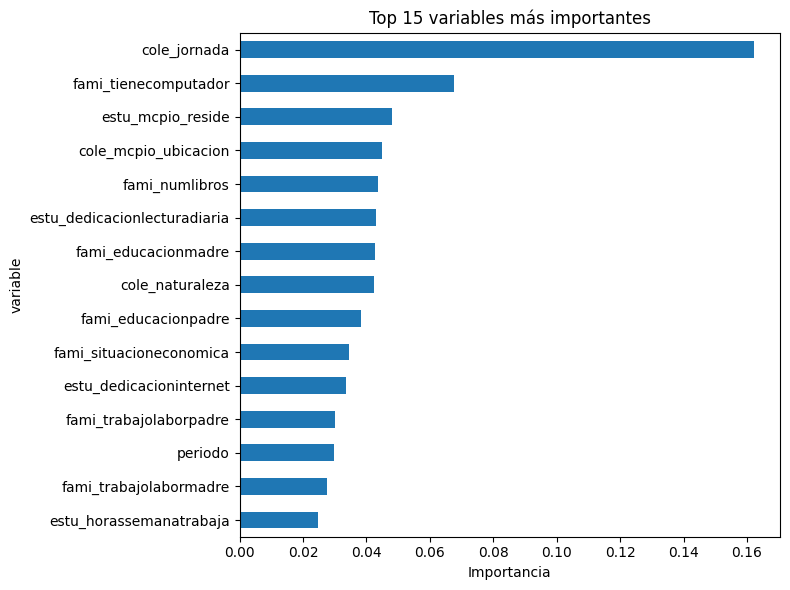

In [53]:
enc = modelo.named_steps["onehot"]
rf = modelo.named_steps["rf"]
nombres = enc.get_feature_names_out(X.columns)


def variable_original(nombre_dummy):
    # Busca la columna original más larga cuyo prefijo coincida
    candidatas = [c for c in X.columns if nombre_dummy.startswith(c + "_")]
    return max(candidatas, key=len) if candidatas else nombre_dummy


imp = (
    pd.DataFrame({"feature": nombres, "importancia": rf.feature_importances_})
    .assign(variable=lambda d: d["feature"].map(variable_original))
    .groupby("variable")["importancia"].sum()
    .sort_values(ascending=False)
)
print("\n=== Importancia por variable ===\n", imp.round(4))

imp.head(15).sort_values().plot(kind="barh", figsize=(8, 6), title="Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


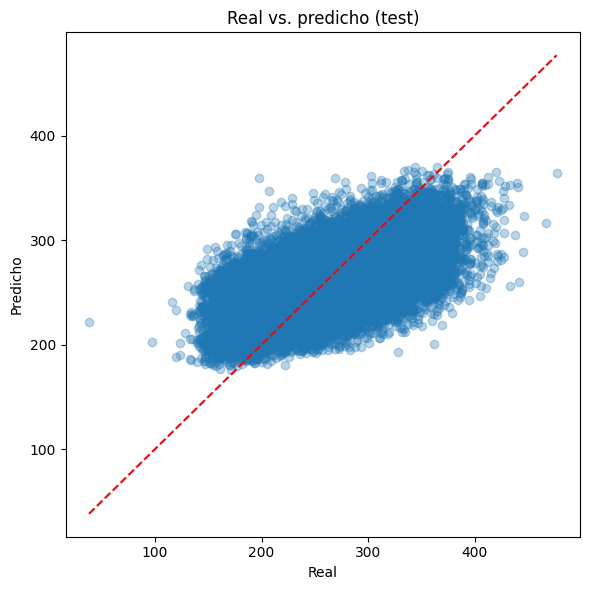

In [54]:
# ---------------------------------------------------------------
# 6. Real vs. predicho (test)
# ---------------------------------------------------------------
pred_test = modelo.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_test, alpha=0.3)
lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lim, lim, "r--")
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs. predicho (test)")
plt.tight_layout()
plt.show()

# XgBoost Regression

In [55]:
# ---------------------------------------------------------------
# 0. Datos (df ya cargado)
# ---------------------------------------------------------------
df = df.dropna(subset=['punt_global']).copy()          # sin nulos en el objetivo

y = df['punt_global']
X = df.drop(columns=['punt_global']).fillna('Sin dato').astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
# ---------------------------------------------------------------
# 1. Categóricas nativas de XGBoost (sin One-Hot: más rápido y liviano)
#    Las categorías se definen con TRAIN; las nuevas en test pasan a NaN,
#    que XGBoost maneja sin problema.
# ---------------------------------------------------------------
categorias = {c: X_train[c].astype("category").cat.categories for c in X.columns}


def a_categorico(Xd):
    Xc = Xd.copy()
    for c in Xc.columns:
        Xc[c] = pd.Categorical(Xc[c], categories=categorias[c])
    return Xc


X_train_c = a_categorico(X_train)
X_test_c = a_categorico(X_test)


In [57]:
# ---------------------------------------------------------------
# 2. Métricas: RMSE, MAE, MAPE, R2
# ---------------------------------------------------------------
def calcular_metricas(y_real, y_pred):
    y_real = np.asarray(y_real)
    y_pred = np.asarray(y_pred)
    mask = y_real != 0  # MAPE no está definido si y_real = 0
    return {
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "MAE": mean_absolute_error(y_real, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_real[mask], y_pred[mask]) * 100,
        "R2": r2_score(y_real, y_pred),
    }


In [58]:
# ---------------------------------------------------------------
# 3. Búsqueda de hiperparámetros (rápida, validación cruzada sobre TRAIN)
#    Learning rate alto y pocos árboles solo para explorar;
#    el modelo final usa learning rate bajo + early stopping.
# ---------------------------------------------------------------
param_dist = {
    "max_depth": [3, 4, 6, 8],
    "min_child_weight": [1, 5, 10],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.8, 1.0],
    "reg_lambda": [1, 5, 10],
}

busqueda = RandomizedSearchCV(
    XGBRegressor(
        tree_method="hist",
        enable_categorical=True,
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,          # XGBoost ya paraleliza internamente
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=1,               # evita saturar el CPU con doble paralelismo
    verbose=1,
)
busqueda.fit(X_train_c, y_train)

print("\nMejores hiperparámetros:", busqueda.best_params_)
print("MAE en validación cruzada:", round(-busqueda.best_score_, 3))



Fitting 3 folds for each of 10 candidates, totalling 30 fits

Mejores hiperparámetros: {'subsample': 0.7, 'reg_lambda': 1, 'min_child_weight': 10, 'max_depth': 6, 'colsample_bytree': 0.8}
MAE en validación cruzada: 33.702


In [59]:
# ---------------------------------------------------------------
# 4. Modelo final: learning rate bajo + early stopping
#    (se reserva 15% de train como validación para frenar a tiempo)
# ---------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_c, y_train, test_size=0.15, random_state=42
)

modelo = XGBRegressor(
    tree_method="hist",
    enable_categorical=True,
    n_estimators=2000,          # tope; early stopping decide cuántos usar
    learning_rate=0.05,
    early_stopping_rounds=50,
    eval_metric="mae",
    random_state=42,
    n_jobs=-1,
    **busqueda.best_params_,
)
modelo.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print("\nÁrboles usados (best_iteration):", modelo.best_iteration + 1)




Árboles usados (best_iteration): 602


In [60]:
# ---------------------------------------------------------------
# 5. Evaluación en train y test
# ---------------------------------------------------------------
met = {
    "train": calcular_metricas(y_train, modelo.predict(X_train_c)),
    "test": calcular_metricas(y_test, modelo.predict(X_test_c)),
}
print("\n=== Métricas del modelo final ===")
print(pd.DataFrame(met).round(3))

# Baseline: predecir siempre la media de train
base = calcular_metricas(y_test, np.full(len(y_test), y_train.mean()))
print("\n=== Baseline (predecir la media) en test ===")
print(pd.Series(base).round(3))




=== Métricas del modelo final ===
           train    test
RMSE      37.971  41.683
MAE       30.345  33.526
MAPE (%)  12.411  13.705
R2         0.479   0.368

=== Baseline (predecir la media) en test ===
RMSE        52.445
MAE         43.215
MAPE (%)    17.836
R2          -0.000
dtype: float64



=== Importancia por variable ===
 fami_tienecomputador             0.1325
cole_jornada                     0.1098
periodo                          0.0812
estu_genero                      0.0661
fami_situacioneconomica          0.0599
estu_dedicacionlecturadiaria     0.0385
fami_numlibros                   0.0382
fami_tieneinternet               0.0362
cole_mcpio_ubicacion             0.0305
cole_naturaleza                  0.0298
estu_dedicacioninternet          0.0289
cole_area_ubicacion              0.0261
estu_horassemanatrabaja          0.0257
fami_educacionmadre              0.0247
fami_comecerealfrutoslegumbre    0.0199
fami_cuartoshogar                0.0197
fami_educacionpadre              0.0174
estu_mcpio_reside                0.0173
fami_comelechederivados          0.0166
fami_tieneserviciotv             0.0159
fami_estratovivienda             0.0156
fami_personashogar               0.0154
fami_tienemotocicleta            0.0153
fami_tieneautomovil              0.0151
cole_

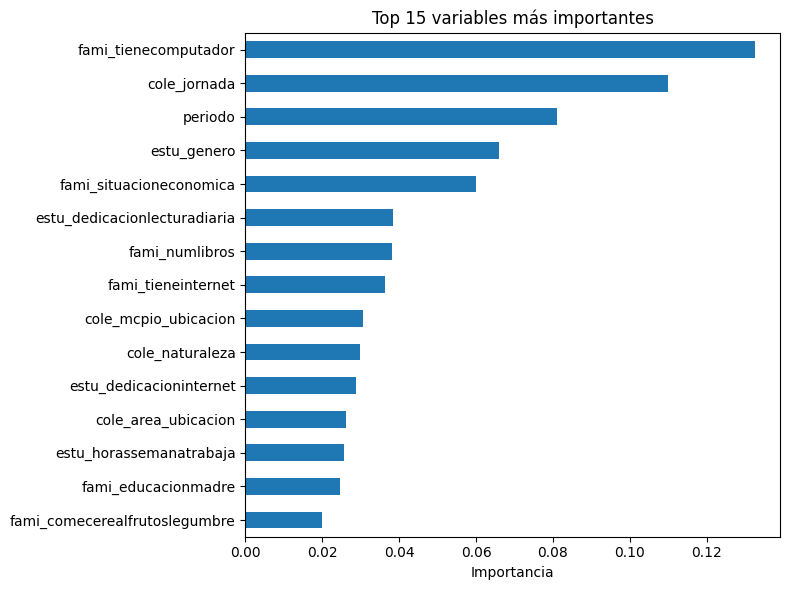

In [61]:
# ---------------------------------------------------------------
# 6. Importancia de variables (ya viene por variable original)
# ---------------------------------------------------------------
imp = (
    pd.Series(modelo.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)
print("\n=== Importancia por variable ===\n", imp.round(4))

imp.head(15).sort_values().plot(kind="barh", figsize=(8, 6), title="Top 15 variables más importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


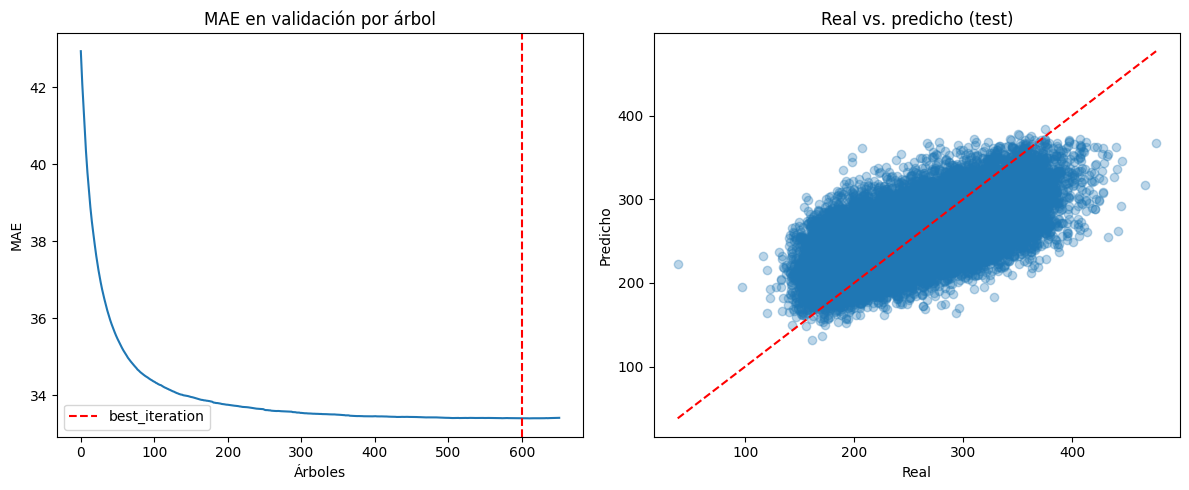

In [62]:
# ---------------------------------------------------------------
# 7. Curva de aprendizaje y real vs. predicho
# ---------------------------------------------------------------
curva = modelo.evals_result()["validation_0"]["mae"]
pred_test = modelo.predict(X_test_c)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(curva)
ax[0].axvline(modelo.best_iteration, color="r", linestyle="--", label="best_iteration")
ax[0].set(title="MAE en validación por árbol", xlabel="Árboles", ylabel="MAE")
ax[0].legend()

ax[1].scatter(y_test, pred_test, alpha=0.3)
lim = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax[1].plot(lim, lim, "r--")
ax[1].set(title="Real vs. predicho (test)", xlabel="Real", ylabel="Predicho")
plt.tight_layout()
plt.show()